In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Univariate fitting

Thin wrapper around `paper.experiments.univariate`.


In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import synthetic
from paper.experiments.univariate import PROFILES, run_profile
from paper.plotting import plot_scaling, plot_target_gallery
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams["figure.dpi"] = 140


In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = synthetic.default_raw_path("univariate", profile_name)
plot_target_kind = "monotone"

In [4]:
if raw_path.exists():
    raw = pd.read_csv(raw_path)
else:
    raw = run_profile(profile)
    synthetic.write_csv(raw, raw_path)

expected_models = {"unconstrained", "monotone"}
if not expected_models <= set(raw["model"].unique()):
    raise ValueError(f"{raw_path} does not contain {sorted(expected_models)}; rerun this profile")

summary = summarize_raw(raw, profile.train_sizes)
plot_summary = summary.loc[summary["target_kind"] == plot_target_kind].copy()
plot_summary.head()

,target_kind,complexity,noise_std,model,dim,batch_size,train_size,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
234,monotone,5,0.0,monotone,5,32,32,0.1,0.424550,0.315630,0.522116,96
235,monotone,5,0.0,monotone,5,32,64,0.1,0.273086,0.204148,0.352694,96
236,monotone,5,0.0,monotone,5,32,160,0.1,0.195848,0.150875,0.241419,96
237,monotone,5,0.0,monotone,5,32,320,0.1,0.185704,0.137271,0.225137,96
238,monotone,5,0.0,monotone,5,32,640,0.1,0.155196,0.123390,0.210813,96


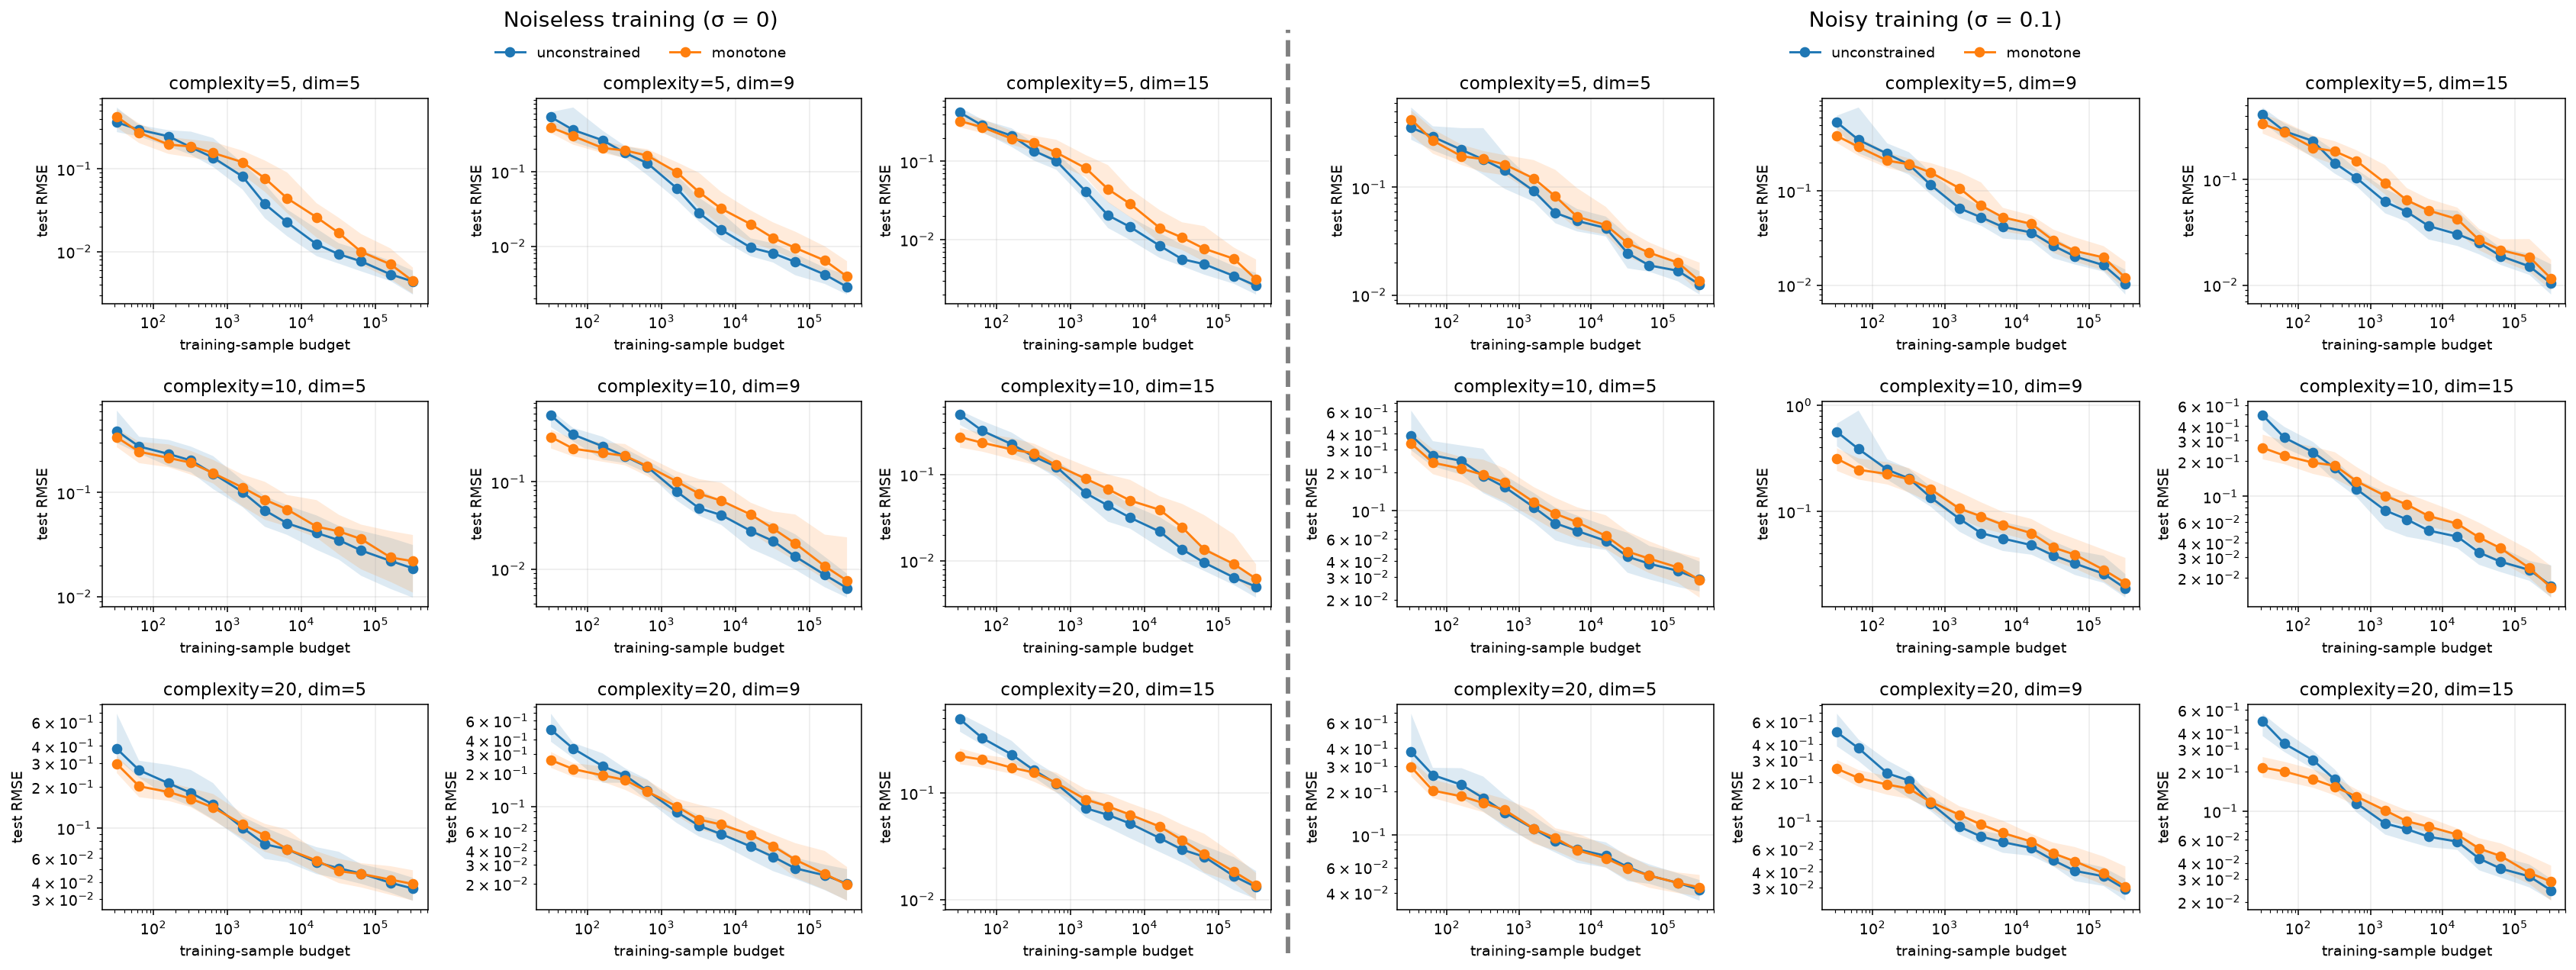

In [5]:
plot_scaling(plot_summary);

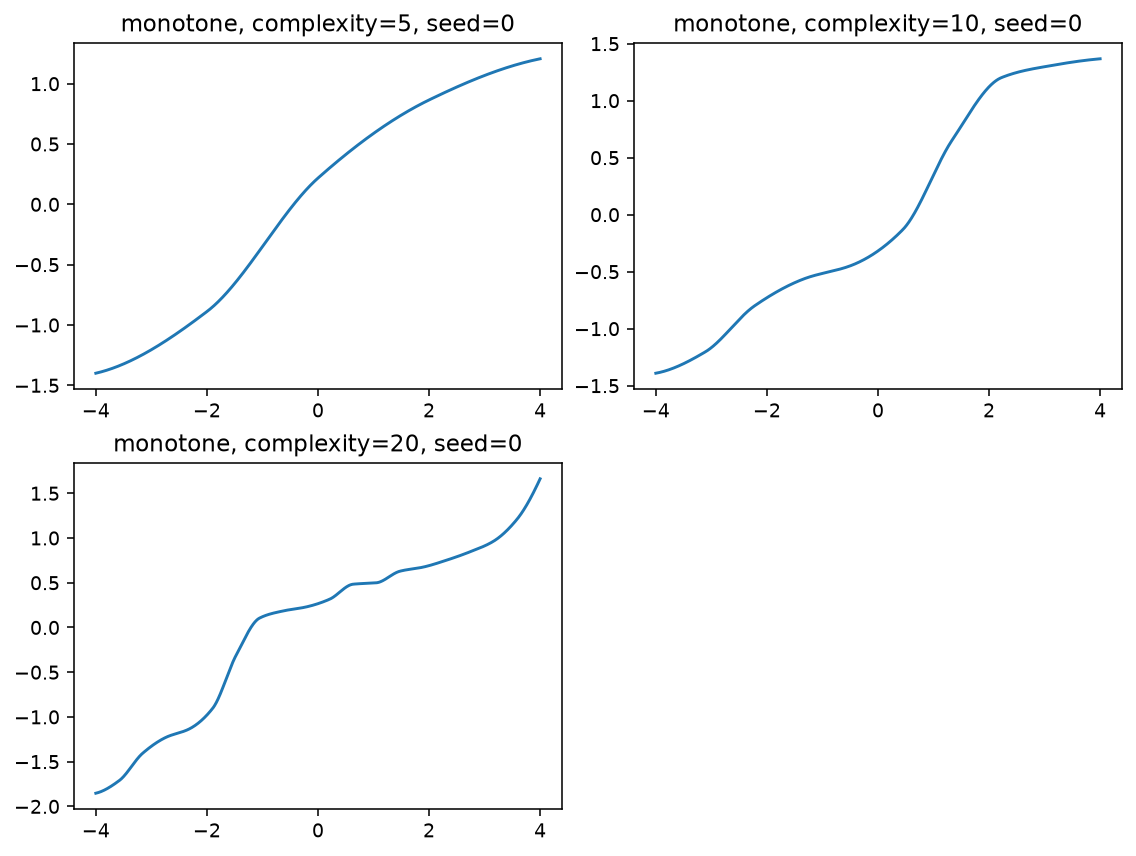

In [6]:
plot_target_gallery([
    TargetSpec(kind=plot_target_kind, complexity=complexity, seed=0)
    for complexity in profile.complexities
]);